# Perceval Quest
#### Author: *Valentin Deumier*

Our goal is to start by creating a 'classical' neural network and train it on the famous MNIST handwritten digits dataset, and then try to upgrade it by using Linear Optical Quantum Computing, in hope to increase the accuracy of the model with a lower amount of parameters.

### <u>2: A hybrid model</u>

In [2]:
import numpy as np
from scipy import linalg
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.optimize import minimize
from tqdm import tqdm
import time

from dotenv import load_dotenv
import os
print(np.__version__)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Softmax
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model

import perceval as pcvl
import perceval.providers.scaleway as scw
import perceval.components as comp
from perceval.rendering.circuit import SymbSkin, PhysSkin
from perceval import Circuit
from perceval import catalog
print(pcvl.__version__)

# Parameters
IMG_SIZE = 28
NUM_CLASSES = 10
BATCH_SIZE = 64
EPOCHS = 30

2.0.2
0.12.2


In [3]:
# Scaleway session initialization

load_dotenv()

__SCW_PROJECT_ID = os.getenv("SCW_PROJECT_ID")
__SCW_TOKEN = os.getenv("SCW_SECRET_KEY")

session = scw.Session(
    project_id=__SCW_PROJECT_ID,
    token=__SCW_TOKEN,
    platform="sim:sampling:l4",  # Simulation on Nvidia L4 GPU
    max_idle_duration_s=1200,  # session is automatically revoked after 6 minutes without any new job
    max_duration_s=3600,  # session is automatically revoked after one hour
)

In [4]:
# Data into numpy arrays
def load_data(filename):

    data = pd.read_csv(filename)
    X = np.array(data['image'].str.split(',', expand=True).values)

    # Remove the [ ] from the image data (fastest method I found)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            X[i, j] = X[i, j].replace('[', '').replace(']', '')
    X = X.astype(float)

    y = data['label'].values

    X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)/255.0      # Reshape and normalize
    return X, y

# Get the absolute path to the data folder
script_dir = os.getcwd()
data_dir = os.path.join(script_dir, 'data')

# Load the data
train_file = os.path.join(data_dir, 'train.csv')
X_train, y_train = load_data(train_file)
val_file = os.path.join(data_dir, 'val.csv')
X_val, y_val = load_data(val_file)
print(X_train.shape, y_train.shape, X_val.shape, y_val.shape)

# Divide the image resolution by 2 using max pooling
X_train = np.array(tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(X_train))
X_val = np.array(tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(X_val))

# X_train = np.array(tf.keras.layers.AveragePooling2D(pool_size=(2, 2))(X_train))
# X_val = np.array(tf.keras.layers.AveragePooling2D(pool_size=(2, 2))(X_val))

print(X_train.shape, y_train.shape, X_val.shape, y_val.shape)
# print(X_train[0])
EFF_IMG_SIZE = X_train.shape[1]


(6000, 28, 28, 1) (6000,) (600, 28, 28, 1) (600,)
(6000, 14, 14, 1) (6000,) (600, 14, 14, 1) (600,)


The idea here is to encode the image data into quantum data while preserving the 2-dimensional structure of the image. \
\
Like in the CNN model, we want neighbours pixels to remain close to each other in the quantum representation so that we can perform "local" transformation (the equivalent of convoluting the image with a kernel), so the representation has to be continuous along both axis.\
This means that we can't flatten the data, so we can't use basis, angle or amplitude embedding.\
\
An idea could be to encode the image in a matrix representation of a unitary transformation (that could also be parametrized, and have its parameters be optimized).\
\
Being inspired by the solution of Schrodinger's equation for a time-independant Hamiltonian, we are going to represent the image $\mathbf{x}$ as the resulting evolution operator :

$$ U_t(\mathbf{x}) = \exp(-iH_{\mathbf{x}}t) $$

Where $H_{\mathbf{x}}$ is the symetric part of our image matrix (so that $U_t(\mathbf{x})$ is unitary):

$$ H_{\mathbf{x}} = \frac{\mathbf{x} + \mathbf{x}^T}{2} $$

with $t \in \mathbb{R}$ a parameter that we can tweak.

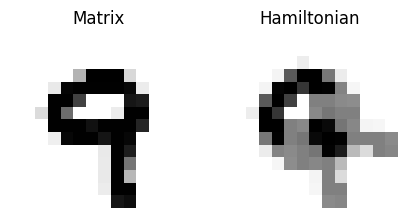

In [5]:
def toHamiltonian(x):
    H = 0.5*(x[:, :, 0] + x[:, :, 0].T)
    return H

def plot_hamiltonian(x):
    L = [x, toHamiltonian(x)]
    labels = ['Matrix', 'Hamiltonian']
    fig, axes = plt.subplots(1, 2, figsize=(5, 5))
    for i in range(2):
        axes[i].imshow(L[i], cmap='gray_r')
        axes[i].set_title(labels[i])
        axes[i].axis('off')
    plt.show()

# Plot the first image and its Hamiltonian
plot_hamiltonian(X_train[1])

This exemple shows that almost half of the information contained in the input image is lost during the encoding process, as we only keep its symetrical part.

Another way of constructing a unitary matrix is by using the *unitary dilation theorem*:

Let $A \in \mathcal{M}_n(\mathbb{C})$ such that its spectral norm verifies $||A|| \le 1$, then

$$ U_A = \begin{bmatrix} A & \sqrt{\mathbb{I} - A A^\dagger} \\ \sqrt{\mathbb{I} - A^\dagger A} & -A^\dagger \end{bmatrix} $$

is a $2n \times 2n$ unitary matrix. 

Therefore, if we normalize our input image, we can implement it as a 2n modes circuit. Since the whole image information is embedded in the upper half of $U_A$, we will consider a 2n modes circuit but we will effectively only work with the first n modes.

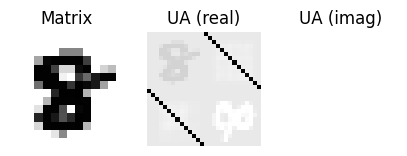

(5790, 14, 14, 1) (5790,) (587, 14, 14, 1) (587,)


In [6]:
def U(x: np.ndarray, t: float) -> np.ndarray:
    """Compute the unitary operator associated with the Hamiltonian x and time t"""
    H = toHamiltonian(x)
    return linalg.expm(-1j*H*t)

def UA(x: np.ndarray) -> np.ndarray:
    """Compute the unitary operator using unitary dilation"""
    x = x[:, :, 0]
    x = x / (1.7 * np.linalg.norm(x, ord=2))        # The 1.7 factor is to ensure that most computations pass the numpy is_unitary test
    identity = np.eye(EFF_IMG_SIZE)
    B = np.block([
        [x, linalg.sqrtm(identity - x @ x.T)],
        [linalg.sqrtm(identity - x.T @ x), -x.T]
    ])
    return B

def plot_UA(x):
    L = [x, np.real(UA(x)), np.imag(UA(x))]
    labels = ['Matrix', 'UA (real)', 'UA (imag)']
    fig, axes = plt.subplots(1, 3, figsize=(5, 5))
    for i in range(3):
        axes[i].imshow(L[i], cmap='gray_r')
        axes[i].set_title(labels[i])
        axes[i].axis('off')
    plt.show()

plot_UA(X_train[14])

# Verify that UA(X_train) is unitary
# count = 0
# for i in range(len(X_train)):
#     unitary_check = np.allclose(UA(X_train[i]).conj().T @ UA(X_train[i]), np.eye(2*EFF_IMG_SIZE))
#     if not unitary_check:
#         count += 1
#         # print(y_train[i])
#         # print(f"Is UA(X_val[{i}]) unitary?", unitary_check)

# print(f"Number of non-unitary matrices: {count}")

# Keep only the unitary matrices
train_indices = [np.allclose(UA(x).conj().T @ UA(x), np.eye(2*EFF_IMG_SIZE)) for x in X_train]
X_train = X_train[train_indices]
y_train = y_train[train_indices]
val_indices = [np.allclose(UA(x).conj().T @ UA(x), np.eye(2*EFF_IMG_SIZE)) for x in X_val]
X_val = X_val[val_indices]
y_val = y_val[val_indices]

print(X_train.shape, y_train.shape, X_val.shape, y_val.shape)
# print(UA(X_train[0]))

To reproduce the local effect of the convolution, the next layer will be constituted of a brickwork layout of 2 modes circuits that are acting on modes close to each other.\
\
The operator associated with this layer will be denoted $V(\mathbf{\omega})$, with $\mathbf{\omega}$ being the array of parameters of the 2 modes circuits.\

In [7]:
def brickwork(
    omega: np.ndarray,
    num_modes: int,
) -> Circuit:
    """
    Create a brickwork circuit with generic 2 modes circuits.
    Args:   
        omega         : generic 2 modes circuits parameters (shape: [EFF_IMG_SIZE - 1, 4])
        num_modes : Width of circuit
    Returns:
        Circuit
    """
    circ = Circuit(num_modes)
    even_modes = np.arange(0, num_modes - 1, 2)
    odd_modes = np.arange(1, num_modes - 1, 2)

    for k in even_modes:
        params = omega[int(k)]
        circ.add(int(k), catalog["generic 2 mode circuit"].build_circuit(theta=params[0], phi_tl=params[1], phi_bl=params[2], phi_tr=params[3]))
    for j in odd_modes:
        params = omega[int(j)]
        circ.add(int(j), catalog["generic 2 mode circuit"].build_circuit(theta=params[0], phi_tl=params[1], phi_bl=params[2], phi_tr=params[3]))

    return circ

def brickwork_BS(
    omega: np.ndarray,
    num_modes: int,
) -> Circuit:
    """
    Create a brickwork circuit with beam splitters.
    Args:   
        omega         : BS parameters (len = num_modes - 1)
        num_modes : Width of circuit
    Returns:
        Circuit
    """
    circ = Circuit(num_modes)
    even_modes = np.arange(0, num_modes - 1, 2)
    odd_modes = np.arange(1, num_modes - 1, 2)

    for k in even_modes:
        circ.add(int(k), comp.BS(omega[int(k)]))
    for j in odd_modes:
        circ.add(int(j), comp.BS(omega[int(j)]))
   
    return circ

In [8]:
if EFF_IMG_SIZE % 2 == 0:       # Number of photons
    N = EFF_IMG_SIZE//2      
else:
    N = EFF_IMG_SIZE//2 + 1

m = EFF_IMG_SIZE * 2      # Number of modes   
L = 6       # Number of layers

# Input state with N photons and m modes
input_state = pcvl.BasicState([1, 0]*N + [0]*(m-2*N))
print("Input state:", input_state)

# Random parameters for the circuit initialization
omega_params = np.random.uniform(0, 2*np.pi, (L, (EFF_IMG_SIZE-1), 4))
BS_params = np.random.uniform(0, 2*np.pi, EFF_IMG_SIZE-1)

print("Total number of parameters:", omega_params.size + BS_params.size)

Input state: |1,0,1,0,1,0,1,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0>
Total number of parameters: 325


**OLD VERSION**

The code will follow the following scheme:

- Use the fonction **create_circuit(x, params)** that create the circuit with L layers $U_A(\mathbf{x}) V(\mathbf{\omega})$ associated to the image $\mathbf{x}$.

- Construct an output of the circuit that can be used in an optimisation algorithm. Here, I had two ideas:
    * Use the average number of photons in each mode in order to compute a softmax probability for each category, and then optimize the circuit using a cross-entropy loss function and standard gradient descent techniques.
    * Use the average number of photons in each mode in order to compute a single value between 0 and 9 (for example, the spatial weighted average over the modes), and here I again had two ideas:
        - Use a genetic algorithm approach
        - Use a regression method to which thresholds are applied in order to categorize.
I have decided to go with the last option.

- Convert the output into a predicted label (not an integer) by computing a weighted average of the spatial distribution

- Compute the MSE loss

- Do a minimization step using derivatives-free algorithms.

Once the minimization of the loss is done, the thresholds will be optimized on the training set in order to yield the highest accuracy


**NEW VERSION**

- Use create_circuit

- Add a classical layer at the end of the optical system.

- Use the categorical_crossentropy loss to:
    * Perform a fast optimization of the classical parameters using Adam
    * Perform a slow optimization of the optical parameters using SPSA or CMA-ES

For the circuit construction, I have realised that the unitary matrix tends to shift photons from one half of the circuit to the other.

Therefore, I have adapted the position of the optical components accordingly.

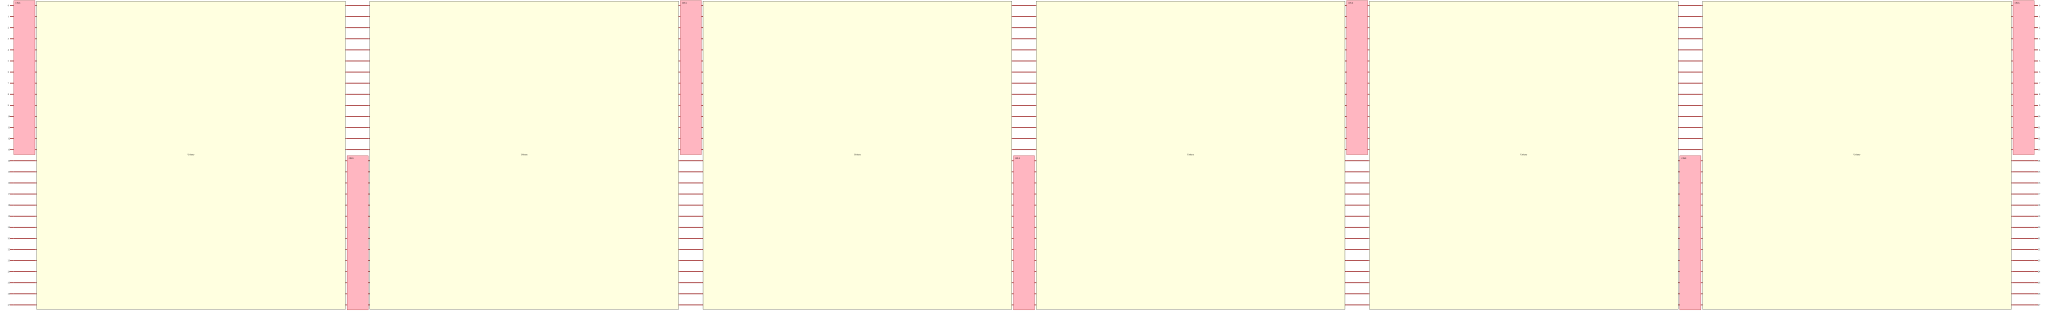

In [9]:
def create_circuit(x, BS_params, omega_params):
    c = Circuit(m)
    c.add(0, brickwork_BS(BS_params, EFF_IMG_SIZE))
    for i in range(L):
        i_odd = 1 - i%2 
        c.add(0, comp.Unitary(U=pcvl.Matrix(UA(x))))
        c.add(i_odd*EFF_IMG_SIZE, brickwork(omega_params[i], EFF_IMG_SIZE))
    return c

c = create_circuit(X_val[9], BS_params, omega_params)
pcvl.pdisplay(c, render_size=0.25)

# ub = Circuit(2, name="ub") // comp.BS() // (0, comp.PS(phi=pcvl.Parameter("φ_a"))) // comp.BS() // (1, comp.PS(phi=pcvl.Parameter("φ_b")))
# c2 = pcvl.Circuit.decomposition(UA(X_train[1]), ub, shape=pcvl.InterferometerShape.TRIANGLE)
# pcvl.pdisplay(c2, render_size=0.25)

For an implementation on a real QPU, we will consider a sample of the circuit output distribution, and the mean circuit output value will be used as the model output before it is converted to a predicted label.

When L is even, almost all photons end up in the top modes, and when L is odd, almost all photons end up in the bottom modes.

In [11]:
N_SAMPLES = 500
# N_SAMPLES = 5000

L_odd = L%2
ps_condition = "["
for i in range(EFF_IMG_SIZE):
    ps_condition += f"{i + L_odd*EFF_IMG_SIZE},"
ps_condition = ps_condition[:-1] + f"] == {N}"
print(ps_condition)
ps = pcvl.utils.postselect.PostSelect(ps_condition)

def sample_prob(x, BS_params, omega_params, processor):
    processor.set_circuit(create_circuit(x, BS_params, omega_params))
    processor.with_input(input_state)
    processor.set_postselection(ps)
    sampler = pcvl.algorithm.Sampler(processor, max_shots_per_call=N_SAMPLES)
    sample_count = sampler.sample_count(N_SAMPLES)
    return sample_count

def mean_output(x, BS_params, omega_params, processor):
    prob_dist = sample_prob(x, BS_params, omega_params, processor)
    mean_output = np.zeros(EFF_IMG_SIZE)
    for output, count in prob_dist['results'].items():
        for i in range(EFF_IMG_SIZE):
            mean_output[i] += output[i + (L%2)*EFF_IMG_SIZE]*count
    return mean_output/N_SAMPLES


[0,1,2,3,4,5,6,7,8,9,10,11,12,13] == 7


**OLD VERSION**

To convert the output state of the circuit into a predicted label, my intuition is to think of the output state as a spatial distribution of guesses:
* The more there are photons close to the top mode, the more the predicted label is close to 0
* The more there are photons close to the bottom mode, the more the predicted label is close to 9

I have decided to take the exponential of this spatial distribution, so that the output is less biased towards middle values like 4 or 5. \
In the label_distribution.py file, it is shown that the *output_to_float_label_flat* function leads to a less biased label distribution.

In [ ]:
# Convert from the repartition of photon in the mean output to a label
def output_to_int_label(output):
    return int(np.round(np.average(range(EFF_IMG_SIZE), weights=np.exp(output) - np.ones(EFF_IMG_SIZE))*9/(EFF_IMG_SIZE - 1)))       # Scale the output to the range [0, 9]

def output_to_float_label(output):
    return np.average(range(EFF_IMG_SIZE), weights=np.exp(output) - np.ones(EFF_IMG_SIZE))*9/(EFF_IMG_SIZE - 1)

def output_to_float_label_flat(output):
    return np.clip(np.sqrt(np.abs(np.average(range(EFF_IMG_SIZE), weights=output) - 6.5))*9 - 1, 0, 10)

**NEW VERSION**

This turned out to not be a great idea as the central limit theorem forces the model to output values sampled from a gaussian distribution, whether or not a transformation to strech it is applied. It is therefore hard for the model to output values that are outside of this gaussian distribution.\
\
The idea to remedy this problem is to have a classical NN layer at the end of the optical system, that takes the mean spatial distribution as input, and outputs a label.

In [12]:
def classical_layer(input_size, hidden_units, num_classes):
    model = Sequential([
        Dense(hidden_units, input_dim=input_size, activation='relu'),
        Dense(num_classes),
        Softmax()
    ])
    return model

# model = classical_layer(EFF_IMG_SIZE, 10, NUM_CLASSES)
# model.summary()

In [13]:
def loss_crossentropy(y_true, y_pred):
    return float(tf.keras.losses.categorical_crossentropy(y_true, y_pred))

def minibatch_loss(X, y, BS_params, omega_params, processor, classifier):
    """ Compute the loss of a minibatch of data 
    Args:
        X : Array of images
        y : Array of labels
        BS_params : Array of BS parameters
        omega_params : Array of omega parameters
    """
    loss = 0
    for i in range(len(X)):
        mean_output_i = mean_output(X[i], BS_params, omega_params, processor)
        label_i = classifier.predict(mean_output_i.reshape(1, -1), verbose=0)
        y_true = to_categorical(y[i], num_classes=NUM_CLASSES).reshape(1, -1)
        loss += loss_crossentropy(y_true, label_i)
    return loss/len(X)

# minibatch_loss(X_train[:BATCH_SIZE], y_train[:BATCH_SIZE], BS_params, omega_params, pcvl.components.processor.Processor("CliffordClifford2017"), classical_layer(EFF_IMG_SIZE, 16, NUM_CLASSES))

In [14]:
def model_accuracy(X, y, BS_params, omega_params, processor, classifier):
    """ Compute the accuracy of a model on a dataset
    Args:
        X : Array of images
        y : Array of labels
        BS_params : Array of BS parameters
        omega_params : Array of omega parameters
    """
    y_pred = []
    for i in range(len(X)):
        mean_output_i = mean_output(X[i], BS_params, omega_params, processor)
        label_i = classifier.predict(mean_output_i.reshape(1, -1), verbose=0)[0].argmax()
        y_pred.append(label_i)
    return accuracy_score(y, y_pred)

def X_to_mean_output(X, BS_params, omega_params, processor):
    mean_outputs = np.zeros((len(X), EFF_IMG_SIZE))
    for i in range(len(X)):
        mean_outputs[i] = mean_output(X[i], BS_params, omega_params, processor)
    return mean_outputs

# print(X_to_mean_output(X_train[:BATCH_SIZE], BS_params, omega_params, pcvl.components.processor.Processor("CliffordClifford2017")))
# print(model_accuracy(X_train[:BATCH_SIZE], y_train[:BATCH_SIZE], BS_params, omega_params, pcvl.components.processor.Processor("CliffordClifford2017"), classical_layer(EFF_IMG_SIZE, 16, NUM_CLASSES)))

Training with SPSA          Total number of parameters  (optical/classical): 565  (325, 240)
Epoch : 0


Training with SPSA: 100%|██████████| 90/90 [40:18<00:00, 26.87s/it]


Total loss: 1.6817352679673911
Validation accuracy: 0.3833049403747871
Epoch : 1


Training with SPSA: 100%|██████████| 90/90 [37:22<00:00, 24.92s/it]


Total loss: 1.7315113525482182
Validation accuracy: 0.36626916524701875
Epoch : 2


Training with SPSA: 100%|██████████| 90/90 [37:13<00:00, 24.81s/it]


Total loss: 1.6120425854856228
Validation accuracy: 0.40545144804088584


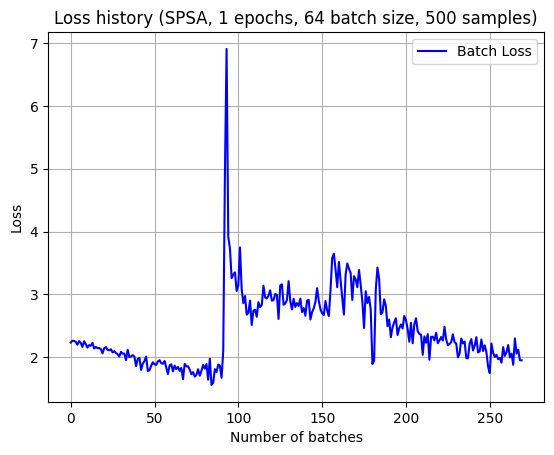

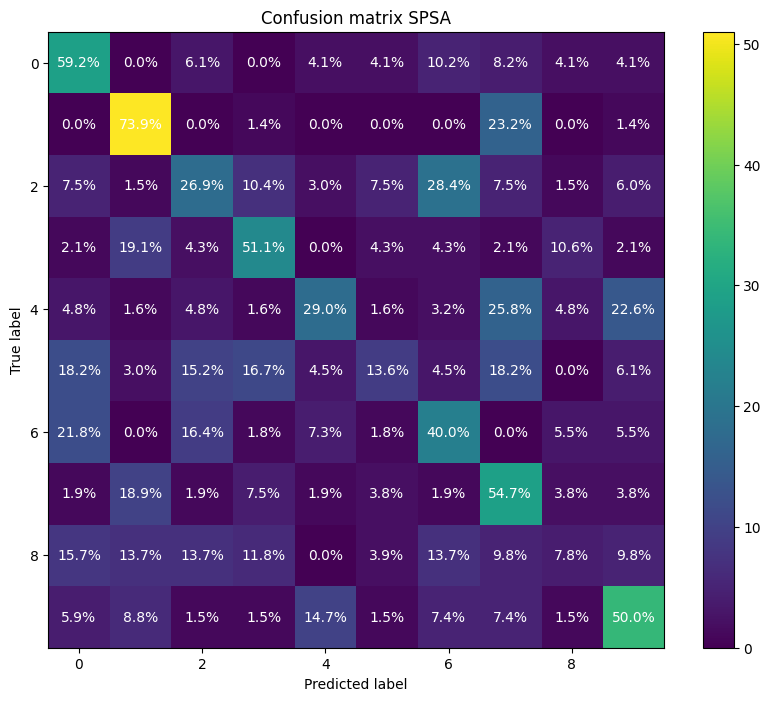

In [23]:
processor = pcvl.components.processor.Processor("CliffordClifford2017")

def train_SPSA(BS_params, omega_params, processor, a=0.01, c=0.05, hidden_units=10, epochs=2):
    """ Train the model using the SPSA algorithm
    Args:
        BS_params : Array of BS parameters
        omega_params : Array of omega parameters
        processor : Quantum processor
        learning_rate : Learning rate of the algorithm
        a : SPSA parameter
        c : SPSA parameter
        max_iter : Maximum number of iterations for the SPSA algorithm
    """
    omega_shape = omega_params.shape
    BS_len = len(BS_params)
    params = np.concatenate([BS_params, omega_params.flatten()])
    classifier = classical_layer(EFF_IMG_SIZE, hidden_units, NUM_CLASSES)
    classifier.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    best_params = params
    best_loss = np.inf
    best_val_acc = 0

    loss_history = []
    total_loss_history = []
    val_acc_history = []

    print(f"Training with SPSA          Total number of parameters  (optical/classical): {params.size + hidden_units*(EFF_IMG_SIZE + NUM_CLASSES)}  ({params.size}, {hidden_units*(EFF_IMG_SIZE + NUM_CLASSES)})")

    for epoch in range(epochs):
        print("Epoch :", epoch)
        shuffled_indices = np.random.permutation(len(X_train))
        num_batches = int(X_train.shape[0]/BATCH_SIZE)

        for k in tqdm(range(num_batches), desc="Training with SPSA"):

            batch_indices = shuffled_indices[k*BATCH_SIZE:min((k+1)*BATCH_SIZE, len(X_train))]
            batch_X = X_train[batch_indices]
            batch_Y = y_train[batch_indices]

            # Perform full minimization on the classical parameters
            classifier.fit(X_to_mean_output(batch_X, BS_params, omega_params, processor), to_categorical(batch_Y, num_classes=NUM_CLASSES), epochs=50, verbose=0)

            # Perform one minimization step on the quantum parameters
            ak = a / (k + 1)**0.602
            ck = c / (k + 1)**0.101
            delta = 2 * np.random.randint(2, size=params.shape) - 1

            params_plus = params + ck * delta
            params_minus = params - ck * delta

            BS_params_plus, omega_params_plus = np.split(params_plus, [BS_len])
            omega_params_plus = omega_params_plus.reshape(omega_shape)
            loss_plus = minibatch_loss(batch_X, batch_Y, BS_params_plus, omega_params_plus, processor, classifier)

            BS_params_minus, omega_params_minus = np.split(params_minus, [BS_len])
            omega_params_minus = omega_params_minus.reshape(omega_shape)
            loss_minus = minibatch_loss(batch_X, batch_Y, BS_params_minus, omega_params_minus, processor, classifier)

            gk = (loss_plus - loss_minus) / (2 * ck * delta)
            params = params - ak * gk

            # print(f"Batch loss (approx): {(loss_plus + loss_minus)/2}           Max gradient value: {np.max(np.abs(gk))}")       
            loss_history.append((loss_plus + loss_minus)/2)  

            
        BS_params, omega_params = np.split(params, [BS_len])
        omega_params = omega_params.reshape(omega_shape)

        # Perform a final training step on the classical parameters
        classifier.fit(X_to_mean_output(X_train, BS_params, omega_params, processor), to_categorical(y_train, num_classes=NUM_CLASSES), epochs=100, verbose=0)

        # Compute the total loss
        loss = minibatch_loss(X_train, y_train, BS_params, omega_params, processor, classifier)
        total_loss_history.append(loss)
        print("Total loss:", loss)

        # Compute the validation accuracy 
        val_acc = model_accuracy(X_val, y_val, BS_params, omega_params, processor, classifier)
        val_acc_history.append(val_acc)
        print("Validation accuracy:", val_acc)

        if val_acc > best_val_acc:
            best_params = params.copy()
            best_val_acc = val_acc

        if loss < best_loss:
            best_loss = loss

    BS_params, omega_params = np.split(best_params, [BS_len])
    omega_params = omega_params.reshape(omega_shape)

    # Compute the confusion matrix
    y_pred = []
    for i in range(len(X_val)):
        mean_output_i = mean_output(X_val[i], BS_params, omega_params, processor)
        label_i = classifier.predict(mean_output_i.reshape(1, -1), verbose=0)[0].argmax()
        y_pred.append(label_i)
    confusion_mtx = confusion_matrix(y_val, y_pred)

    return BS_params, omega_params, loss_history, total_loss_history, val_acc_history, confusion_mtx

BS_params, omega_params, loss_history, total_loss_history, val_acc_history, confusion_mtx = train_SPSA(BS_params, omega_params, processor, a=0.05, c=0.03, epochs=3)

# Save the parameters

# Ensure the directory exists
modelparams_dir = os.path.join(script_dir, 'modelparams')
os.makedirs(modelparams_dir, exist_ok=True)

# Save the parameters
np.save(os.path.join(modelparams_dir, 'BS_params_params.npy'), BS_params)
np.save(os.path.join(modelparams_dir, 'omega_params.npy'), omega_params)
np.save(os.path.join(modelparams_dir, 'loss_history.npy'), loss_history)
np.save(os.path.join(modelparams_dir, 'val_acc_history.npy'), val_acc_history)

# Plot the loss history
plt.plot(loss_history, label='Batch Loss', color='blue')
# plt.plot(total_loss_history, 'x', label='Total Loss', color='orange')
plt.legend()
plt.xlabel("Number of batches")
plt.ylabel("Loss")
plt.title(f"Loss history (SPSA, 1 epochs, {BATCH_SIZE} batch size, {N_SAMPLES} samples)")
plt.grid()

plt.savefig(os.path.join(modelparams_dir, "loss_history.png"))
# plt.show()

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
confusion_mtx_normalized = confusion_mtx.astype('float') / confusion_mtx.sum(axis=1)[:, np.newaxis]

for i in range(confusion_mtx_normalized.shape[0]):
    for j in range(confusion_mtx_normalized.shape[1]):
        plt.text(j, i, f"{confusion_mtx_normalized[i, j]:.1%}", ha='center', va='center', color='white')
plt.imshow(confusion_mtx, cmap='viridis')
plt.colorbar()
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix SPSA")
plt.savefig(os.path.join(modelparams_dir, "confusion_matrix_spsa.png"))
plt.show()

In [ ]:
import cma

processor = pcvl.components.processor.Processor("CliffordClifford2017")

def train_batch_CMAES(BS_params, omega_params, processor, epochs=10, sigma=0.3):
    """ Train the model using the CMA-ES algorithm
    Args:
        BS_params : Array of BS parameters
        omega_params : Array of omega parameters
        processor : Quantum processor
        epochs : Number of epochs
        sigma : Initial standard deviation for the CMA-ES algorithm
    """
    omega_shape = omega_params.shape
    BS_len = len(BS_params)
    params = np.concatenate([BS_params, omega_params.flatten()])
    classifier = classical_layer(EFF_IMG_SIZE, 10, NUM_CLASSES)
    classifier.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    loss_history = []
    val_acc_history = []

    for epoch in range(epochs):
        print("Epoch :", epoch)
        shuffled_indices = np.random.permutation(len(X_train))

        for k in tqdm(range(int(X_train.shape[0] / BATCH_SIZE)), desc="Training with CMA-ES"):
            batch_indices = shuffled_indices[k * BATCH_SIZE: min((k + 1) * BATCH_SIZE, len(X_train))]
            batch_X = X_train[batch_indices]
            batch_Y = y_train[batch_indices]

            def loss_function(params):
                BS_params_f, omega_params_f = np.split(params, [BS_len])
                omega_params_f = omega_params_f.reshape(omega_shape)
                return float(minibatch_loss(batch_X, batch_Y, BS_params_f, omega_params_f, processor, classifier))
            
            # Perform full minimization on the classical parameters
            classifier.fit(X_to_mean_output(batch_X, BS_params, omega_params, processor), to_categorical(batch_Y, num_classes=NUM_CLASSES), epochs=50, verbose=0)

            # Perform one minimization step on the optical parameters
            es = cma.CMAEvolutionStrategy(params, sigma)
            es.optimize(loss_function, iterations=1, verb_disp=0)
            params = es.result.xbest
            loss = es.result.fbest
            loss_history.append(loss)
            print("Loss :", loss)

        BS_params, omega_params = np.split(params, [BS_len])
        omega_params = omega_params.reshape(omega_shape)

        # Perform a final training step on the classical parameters
        classifier.fit(X_to_mean_output(X_train, BS_params, omega_params, processor), to_categorical(y_train, num_classes=NUM_CLASSES), epochs=100, verbose=0)

        # Compute the total loss
        loss = minibatch_loss(X_train, y_train, BS_params, omega_params, processor, classifier)
        loss_history.append(loss)
        print("Total loss:", loss)

        # Compute the validation accuracy
        val_acc = model_accuracy(X_val, y_val, BS_params, omega_params, processor, classifier)
        val_acc_history.append(val_acc)
        print("Validation accuracy:", val_acc)

        # Compute the confusion matrix
        y_pred = []
        for i in range(len(X_val)):
            mean_output_i = mean_output(X_val[i], BS_params, omega_params, processor)
            label_i = classifier.predict(mean_output_i.reshape(1, -1), verbose=0)[0].argmax()
            y_pred.append(label_i)
        confusion_mtx = confusion_matrix(y_val, y_pred)

    return BS_params, omega_params, loss_history, val_acc_history, confusion_mtx

# Example usage
BS_params, omega_params, loss_history, val_acc_history, confusion_mtx = train_batch_CMAES(BS_params, omega_params, processor, epochs=1, sigma=0.3)

# Save the parameters

# Ensure the directory exists
modelparams_dir = os.path.join(script_dir, 'modelparams')
os.makedirs(modelparams_dir, exist_ok=True)

# Save the parameters
np.save(os.path.join(modelparams_dir, 'BS_params_params.npy'), BS_params)
np.save(os.path.join(modelparams_dir, 'omega_params.npy'), omega_params)
# np.save(os.path.join(modelparams_dir, 'loss_history.npy'), loss_history)
# np.save(os.path.join(modelparams_dir, 'val_acc_history.npy'), val_acc_history)

# Plot the loss history
# plt.plot(loss_history)
# plt.xlabel("Number of batches")
# plt.ylabel("Loss")
# plt.title("Loss history")
# plt.grid()

# plt.savefig(os.path.join(modelparams_dir, "loss_history.png"))
# plt.show()

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
confusion_mtx_normalized = confusion_mtx.astype('float') / confusion_mtx.sum(axis=1)[:, np.newaxis]

for i in range(confusion_mtx_normalized.shape[0]):
    for j in range(confusion_mtx_normalized.shape[1]):
        plt.text(j, i, f"{confusion_mtx_normalized[i, j]:.1%}", ha='center', va='center', color='white')
plt.imshow(confusion_mtx, cmap='viridis')
plt.colorbar()
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix CMA-ES")
plt.savefig(os.path.join(modelparams_dir, "confusion_matrix_cmaes.png"))
plt.show()

Epoch : 0


Training with CMA-ES:   0%|          | 0/90 [00:00<?, ?it/s]

(10_w,21)-aCMA-ES (mu_w=6.2,w_1=27%) in dimension 325 (seed=905446, Mon Mar 24 13:38:13 2025)


Training with CMA-ES:   1%|          | 1/90 [03:17<4:53:37, 197.95s/it]

Loss : 2.2305076122283936
(10_w,21)-aCMA-ES (mu_w=6.2,w_1=27%) in dimension 325 (seed=915790, Mon Mar 24 13:41:30 2025)


...

Loss : 2.264071226119995
(10_w,21)-aCMA-ES (mu_w=6.2,w_1=27%) in dimension 325 (seed=910894, Mon Mar 24 13:44:58 2025)


Training with CMA-ES:   3%|▎         | 3/90 [10:15<4:59:07, 206.29s/it]

Loss : 2.2128779888153076
(10_w,21)-aCMA-ES (mu_w=6.2,w_1=27%) in dimension 325 (seed=920508, Mon Mar 24 13:48:27 2025)


Training with CMA-ES:   3%|▎         | 3/90 [10:24<5:01:55, 208.22s/it]


KeyboardInterrupt: 

In [ ]:
modelparams_dir = os.path.join(script_dir, 'modelparams')
os.makedirs(modelparams_dir, exist_ok=True)

In [ ]:
# Load the parameters

BS_params = np.load(os.path.join(modelparams_dir, 'BS_params_params.npy'))
omega_params = np.load(os.path.join(modelparams_dir, 'omega_params.npy'))
loss_history = np.load(os.path.join(modelparams_dir, 'loss_history.npy'))
val_acc_history = np.load(os.path.join(modelparams_dir, 'val_acc_history.npy'))

print("Validarion accuracy:", val_acc_history[-1])

# Evaluate the model

# print("Training accuracy:", model_accuracy(X_train, y_train, t_params, omega_params))
# print("Validation accuracy:", model_accuracy(X_val, y_val, t_params, omega_params))

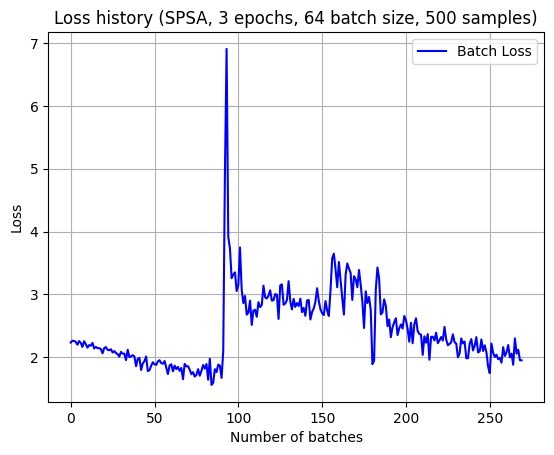

In [24]:
plt.plot(loss_history, label='Batch Loss', color='blue')
# plt.plot(total_loss_history, 'x', label='Total Loss', color='orange')
plt.legend()
plt.xlabel("Number of batches")
plt.ylabel("Loss")
plt.title(f"Loss history (SPSA, 3 epochs, {BATCH_SIZE} batch size, {N_SAMPLES} samples)")
plt.grid()